In [1]:
import pandas as pd
import numpy as np
import yfinance as yf

ticker = "^GSPC"
sp500_data = yf.download(ticker, period="10y", interval="1d")
sp500_data.columns = sp500_data.columns.droplevel('Ticker')

sp500_data['EMA_20'] = sp500_data['Close'].ewm(span=20, adjust=False).mean()
sp500_data['EMA_50'] = sp500_data['Close'].ewm(span=50, adjust=False).mean()

sp500_data['Vol_SMA_20'] = sp500_data['Volume'].rolling(window=20).mean()

delta = sp500_data['Close'].diff()
gains = np.where(delta > 0, delta, 0)
losses = np.where(delta < 0, -delta, 0)
avg_gain = pd.Series(gains, index=sp500_data.index).ewm(alpha=1/14, adjust=False).mean()
avg_loss = pd.Series(losses, index=sp500_data.index).ewm(alpha=1/14, adjust=False).mean()
sp500_data['RSI'] = 100 - (100 / (1 + (avg_gain / avg_loss)))

cond_trend = sp500_data['EMA_20'] > sp500_data['EMA_50']
cond_pullback = (sp500_data['Close'] < sp500_data['EMA_20']) & (sp500_data['Close'] > sp500_data['EMA_50'])
cond_vol = sp500_data['Volume'] > sp500_data['Vol_SMA_20']
cond_rsi = (sp500_data['RSI'] > 40) & (sp500_data['RSI'] < 60)

sp500_data['Entry_Signal'] = np.where(cond_trend & cond_pullback & cond_vol & cond_rsi, 1, 0)

total_trades = sp500_data['Entry_Signal'].sum()
print(f"Total 'Golden Zone' Setups identified: {total_trades}")

[*********************100%***********************]  1 of 1 completed

Total 'Golden Zone' Setups identified: 101


In [9]:
take_profit_pct = 0.04  # 4% Target
stop_loss_pct = 0.02    # 2% Risk

trade_records = []

entry_indices = np.where(sp500_data['Entry_Signal'] == 1)[0]

i = 0
while i < len(entry_indices):
    signal_idx = entry_indices[i]
    
    entry_idx = signal_idx + 1
    
    if entry_idx >= len(sp500_data):
        break 
        
    entry_price = sp500_data['Open'].iloc[entry_idx]
    entry_date = sp500_data.index[entry_idx]
    
    tp_price = entry_price * (1 + take_profit_pct)
    sl_price = entry_price * (1 - stop_loss_pct)
    
    exit_idx = entry_idx
    trade_active = True
    exit_reason = ""
    
    while trade_active and exit_idx < len(sp500_data):
        current_high = sp500_data['High'].iloc[exit_idx]
        current_low = sp500_data['Low'].iloc[exit_idx]
        
        if current_high >= tp_price:
            exit_price = tp_price
            trade_active = False
            exit_reason = "Take Profit"
            
        elif current_low <= sl_price:
            exit_price = sl_price
            trade_active = False
            exit_reason = "Stop Loss"
            
        else:
            exit_idx += 1
            
    if not trade_active:
        exit_date = sp500_data.index[exit_idx]
        trade_return = (exit_price - entry_price) / entry_price
        
        trade_records.append({
            'Entry_Date': entry_date,
            'Exit_Date': exit_date,
            'Entry_Price': entry_price,
            'Exit_Price': exit_price,
            'Return': trade_return,
            'Reason': exit_reason
        })
        
    while i < len(entry_indices) and entry_indices[i] <= exit_idx:
        i += 1

trades_df = pd.DataFrame(trade_records)

print(trades_df.head())

  Entry_Date  Exit_Date  Entry_Price   Exit_Price  Return       Reason
0 2016-04-29 2016-05-19  2071.820068  2030.383667   -0.02    Stop Loss
1 2016-08-29 2016-09-12  2170.189941  2126.786143   -0.02    Stop Loss
2 2017-03-22 2017-06-02  2343.000000  2436.720000    0.04  Take Profit
3 2017-06-30 2017-10-02  2429.199951  2526.367949    0.04  Take Profit
4 2018-02-05 2018-02-05  2741.060059  2686.238857   -0.02    Stop Loss


In [8]:
total_executed_trades = len(trades_df)

winning_trades = len(trades_df[trades_df['Reason'] == 'Take Profit'])
win_rate = winning_trades / total_executed_trades

final_cumulative_return = (1 + trades_df['Return']).prod() - 1

print("--- Retail V2 Strategy Final Results ---")
print(f"Total Executed Trades: {total_executed_trades}")
print(f"Win Rate:              {win_rate * 100:.2f}%")
print(f"Total Return:          {final_cumulative_return * 100:.2f}%")

--- Retail V2 Strategy Final Results ---
Total Executed Trades: 43
Win Rate:              44.19%
Total Return:          29.74%


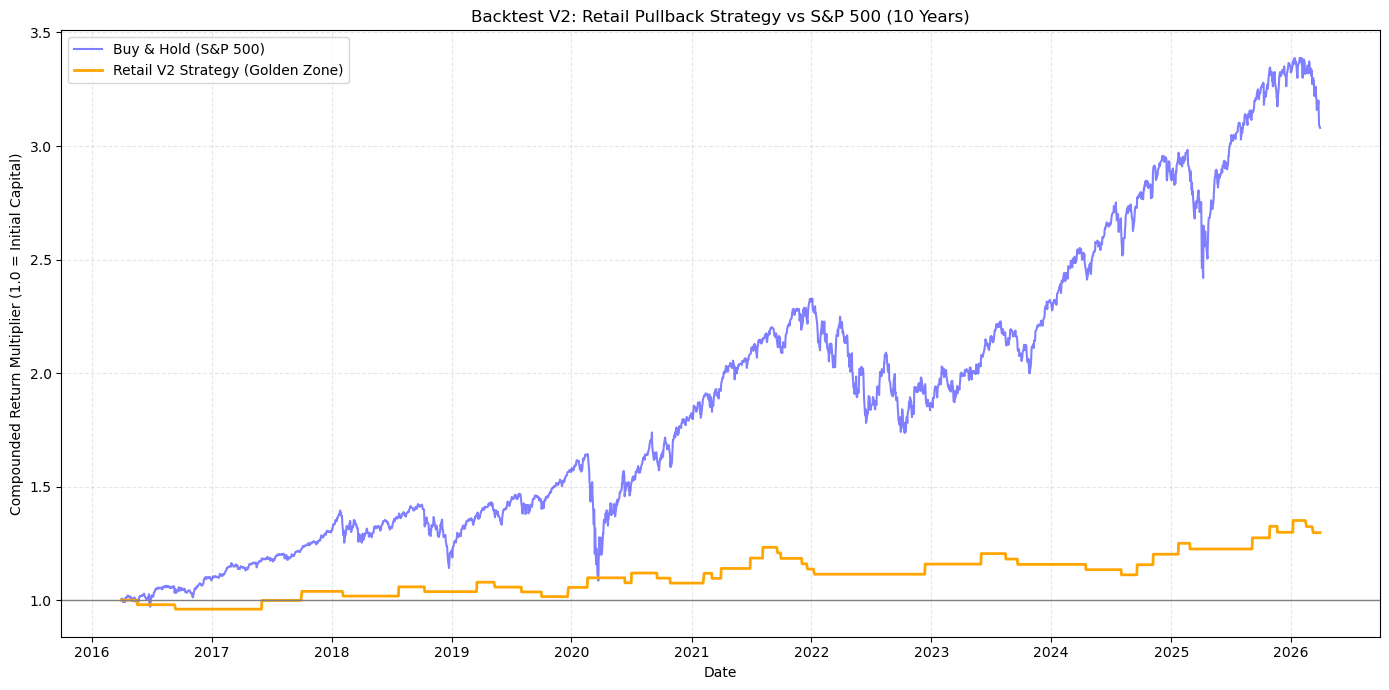

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

v2_portfolio = sp500_data[['Close']].copy()

v2_portfolio['Market_Returns'] = np.log(v2_portfolio['Close'] / v2_portfolio['Close'].shift(1))
v2_portfolio['Compounded_Market'] = np.exp(v2_portfolio['Market_Returns'].cumsum())

v2_portfolio['Strategy_Equity'] = 1.0

if len(trades_df) > 0:
    temp_trades = trades_df.set_index('Exit_Date')
    
    v2_portfolio['Trade_Returns'] = 0.0
    
    v2_portfolio.loc[temp_trades.index, 'Trade_Returns'] = temp_trades['Return']
    
    v2_portfolio['Strategy_Equity'] = (1 + v2_portfolio['Trade_Returns']).cumprod()

fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(v2_portfolio.index, v2_portfolio['Compounded_Market'], label='Buy & Hold (S&P 500)', color='blue', alpha=0.5)
ax.plot(v2_portfolio.index, v2_portfolio['Strategy_Equity'], label='Retail V2 Strategy (Golden Zone)', color='orange', linewidth=2)

ax.set_title('Backtest V2: Retail Pullback Strategy vs S&P 500 (10 Years)')
ax.set_xlabel('Date')
ax.set_ylabel('Compounded Return Multiplier (1.0 = Initial Capital)')
ax.legend(loc='upper left')
ax.grid(True, linestyle='--', alpha=0.3)
ax.axhline(1.0, color='grey', linewidth=1, linestyle='-') # Linea di pareggio

plt.tight_layout()
plt.show()